In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [2]:
# Read config file
config = load_config("conf1.yaml")

# Results folder: a single one for the whole hyperparameter grid (see
# exp1.py) -- each row of df_tot.csv already carries its own
# n_clients/ess/prob_shift/alpha combination.
res_path = Path(config["res_path"])

# Read results (all weighting schemas x all grid combinations, one row per
# (n_clients, ess, prob_shift, alpha, size, rep))
df_tot = pd.read_csv(res_path / f"df_tot.csv")

In [3]:
# Per-repetition (raw df_tot row) derived quantities, computed BEFORE
# aggregating across repetitions: relative gain of each MOSAIC schema over
# plain IDM, on mean JSD (positive = MOSAIC closer to the ground truth than
# IDM alone).
GAIN_COLS = [f"gain_w{w}" for w in (1, 2, 3)]
for w in (1, 2, 3):
    df_tot[f"gain_w{w}"] = (
        df_tot["idm_mean"] - df_tot[f"mos_w{w}_mean"]
    ) / df_tot["idm_mean"]

CONTAIN_COLS = ["idm_gt_contained"] + [f"mos_w{w}_gt_contained" for w in (1, 2, 3)]

# Mean across repetitions, grouped by every grid hyperparameter AND size
# (not just size -- otherwise different hyperparameter combinations would
# be silently averaged together). Covers every JSD statistic, including
# idm_max/mos_w_max -- Grafico 1 below plots mean-to-max directly from
# these columns (see that cell for why min is no longer plotted, even
# though it is still computed and available here).
group_cols = ["n_clients", "ess", "prob_shift", "alpha", "size"]
df_mean = df_tot.drop(columns="rep").groupby(group_cols, as_index=False).mean()

# For the two DERIVED per-repetition quantities (gain, containment), we
# additionally want the standard deviation ACROSS repetitions -- i.e. how
# much the ESTIMATE of the mean itself would vary if the whole experiment
# were repeated, which is a different question from "how wide is a single
# credal set" (already shown by Grafico 1's mean-to-max band). Computed on
# the SAME per-repetition values grouped above, so mean and std are always
# a matched pair.
df_gain_std = df_tot.groupby(group_cols, as_index=False)[GAIN_COLS].std()
df_gain_std = df_gain_std.rename(columns={c: f"{c}_std" for c in GAIN_COLS})
df_contain_std = df_tot.groupby(group_cols, as_index=False)[CONTAIN_COLS].std()
df_contain_std = df_contain_std.rename(columns={c: f"{c}_std" for c in CONTAIN_COLS})

df_mean = df_mean.merge(df_gain_std, on=group_cols).merge(df_contain_std, on=group_cols)

# The intersection ratio gets its own MEDIAN (not mean) plus Q1/Q3: Q1 <=
# median <= Q3 always holds by construction, but NOT for the mean when the
# distribution is skewed (intersection_frac piles up near 1.0 with an
# occasional low outlier rep, which pulls the mean below Q1 -- verified on
# real data). Pairing the mean with an IQR band would be a mismatched pair
# of statistics; median+IQR is the consistent, non-parametric choice (and
# mirrors PriorCN.compute, which already summarizes each repetition via a
# median across mechanisms).
df_mean["intersection_frac_median"] = (
    df_tot.groupby(group_cols)["intersection_frac"].median().to_numpy()
)
df_mean["intersection_frac_q1"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.25).to_numpy()
)
df_mean["intersection_frac_q3"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.75).to_numpy()
)
df_mean.head()

,n_clients,ess,prob_shift,alpha,size,mle,idm_min,idm_mean,idm_max,mos_w1_min,...,gain_w1_std,gain_w2_std,gain_w3_std,idm_gt_contained_std,mos_w1_gt_contained_std,mos_w2_gt_contained_std,mos_w3_gt_contained_std,intersection_frac_median,intersection_frac_q1,intersection_frac_q3
0,5,2,0.0,10,5,0.122527,0.122527,0.163603,0.392325,0.081785,...,0.035209,0.044970,0.058586,0.070711,0.000000,0.000000,0.000000,1.0000,1.00000,1.00000
1,5,2,0.0,10,55,0.014608,0.014608,0.023574,0.058076,0.011735,...,0.101623,0.124462,0.094254,0.141421,0.000000,0.000000,0.070711,1.0000,1.00000,1.00000
2,5,2,0.0,10,105,0.009146,0.008830,0.012693,0.029178,0.006848,...,0.197084,0.179800,0.207640,0.000000,0.070711,0.070711,0.070711,0.9375,0.90625,0.96875
3,5,2,0.5,10,5,0.122527,0.122527,0.163603,0.392325,0.083484,...,0.015534,0.043027,0.032765,0.070711,0.000000,0.000000,0.000000,1.0000,1.00000,1.00000
4,5,2,0.5,10,55,0.014608,0.014608,0.023574,0.058076,0.012401,...,0.127531,0.139037,0.090823,0.141421,0.000000,0.000000,0.070711,0.9375,0.90625,0.96875


In [4]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update(
    {
        # ---- base ----
        "figure.figsize": [7, 4],
        "font.size": 9,
        # ---- axes ----
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        # ---- legend ----
        "legend.fontsize": 10,
        # "legend.labelspacing": 0.3,
        # ---- ticks ----
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        # ---- lines ----
        "lines.linewidth": 1.0,
        # ---- dpi ----
        "figure.dpi": 300,
        "savefig.dpi": 300,
        # # ---- tex ----
        # "text.usetex": True,
    }
)

In [5]:
# Facet grid: rows = (prob_shift, alpha) combinations, columns =
# (n_clients, ess) combinations.
row_vals = sorted(
    set(df_mean[["prob_shift", "alpha"]].itertuples(index=False, name=None))
)
col_vals = sorted(set(df_mean[["n_clients", "ess"]].itertuples(index=False, name=None)))
print(
    f"Grid: {len(row_vals)} row(s) (prob_shift, alpha) x {len(col_vals)} col(s) (n_clients, ess)"
)


def row_label(p, a):
    # alpha is irrelevant (and deduplicated away, see exp1.hyperparameter_combos)
    # whenever prob_shift == 0.0.
    return f"prob_shift={p}" if p == 0 else f"prob_shift={p}, alpha={a}"

Grid: 3 row(s) (prob_shift, alpha) x 4 col(s) (n_clients, ess)


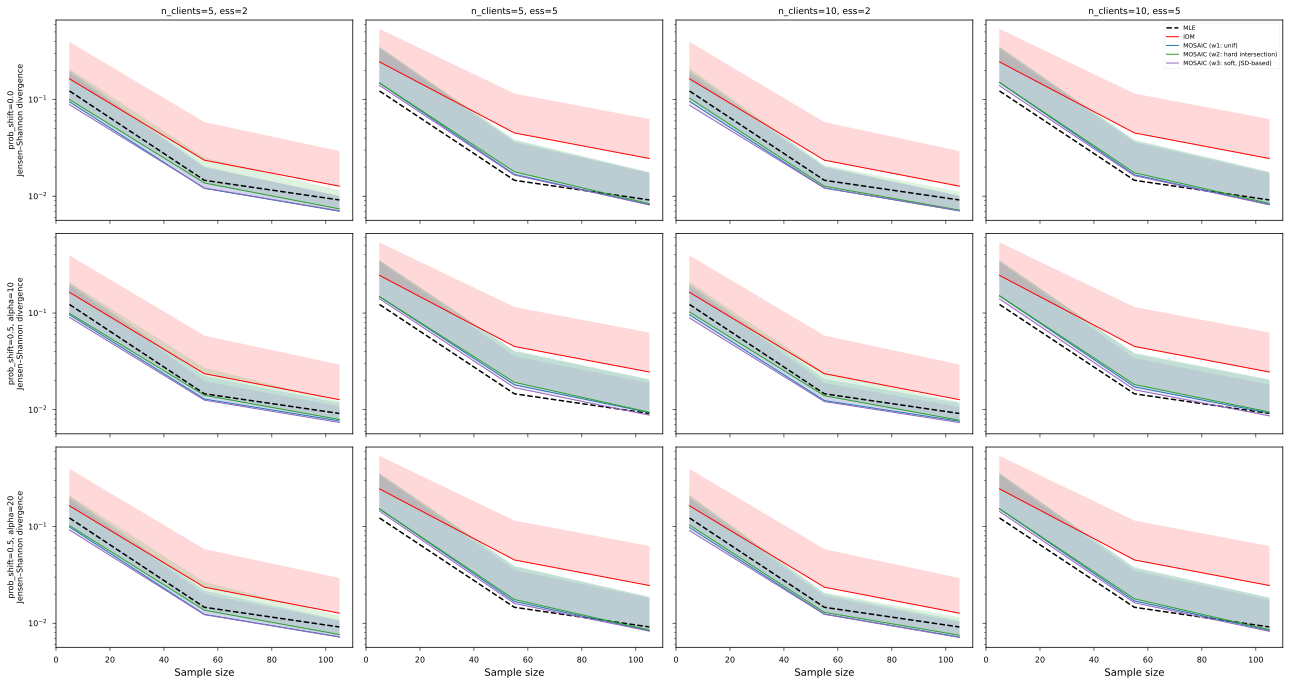

In [6]:
# Grafico 1: one panel per (prob_shift, alpha) x (n_clients, ess)
# combination. Mean-to-max band (NOT min-to-max): the max is exact (vertex
# enumeration, since JSD is convex in its second argument) and already
# conveys the credal set's worst case -- the minimum is the weakest, most
# easily-gamed evidence for "MOSAIC is good" (a wider, less informative
# credal set trivially achieves a lower minimum just by having more
# volume, not because it is a better estimate), so it is intentionally not
# plotted here, even though it is still computed and saved in df_tot.csv.
mos_colors = {1: "tab:blue", 2: "tab:green", 3: "tab:purple"}
mos_labels = {
    1: "MOSAIC (w1: unif)",
    2: "MOSAIC (w2: hard intersection)",
    3: "MOSAIC (w3: soft, JSD-based)",
}

fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.2 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (p, a) in enumerate(row_vals):
    for j, (nc, ess) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        ax.plot(
            sub["size"], sub["mle"], "--", linewidth=1.5, color="black", label="MLE"
        )
        ax.fill_between(
            sub["size"], sub["idm_mean"], sub["idm_max"], color="red", alpha=0.15
        )
        ax.plot(sub["size"], sub["idm_mean"], color="red", label="IDM")
        for w, color in mos_colors.items():
            ax.fill_between(
                sub["size"],
                sub[f"mos_w{w}_mean"],
                sub[f"mos_w{w}_max"],
                color=color,
                alpha=0.15,
            )
            ax.plot(sub["size"], sub[f"mos_w{w}_mean"], color=color, label=mos_labels[w])

        ax.set_yscale("log")
        if i == 0:
            ax.set_title(f"n_clients={nc}, ess={ess}", fontsize=9)
        if j == 0:
            ax.set_ylabel(
                f"{row_label(p, a)}\nJensen–Shannon divergence", fontsize=8
            )
        if i == len(row_vals) - 1:
            ax.set_xlabel("Sample size")

axes[0][-1].legend(loc="upper right", fontsize=6)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(f"{res_path}.svg", dpi=1200, bbox_inches="tight", transparent=False)

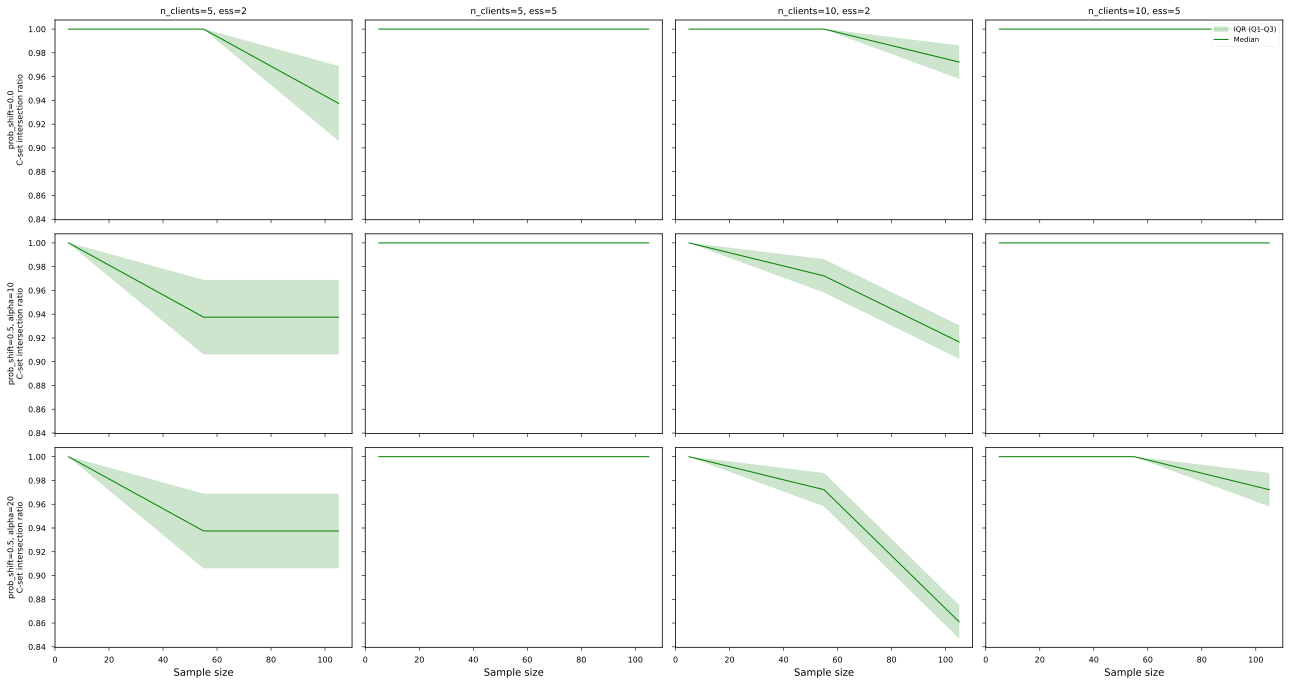

In [7]:
# Plot: intersection ratio, one panel per grid combination. Meaningful for
# weighting=2 (hard intersection); computed and available for all schemas
# since it only depends on the target/candidates' own credal sets, not on
# the weighting formula (see exp1.py).
fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.2 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (p, a) in enumerate(row_vals):
    for j, (nc, ess) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        ax.fill_between(
            sub["size"],
            sub["intersection_frac_q1"],
            sub["intersection_frac_q3"],
            color="green",
            alpha=0.2,
            label="IQR (Q1-Q3)",
        )
        ax.plot(
            sub["size"], sub["intersection_frac_median"], color="green", label="Median"
        )

        if i == 0:
            ax.set_title(f"n_clients={nc}, ess={ess}", fontsize=9)
        if j == 0:
            ax.set_ylabel(
                f"{row_label(p, a)}\nC-set intersection ratio", fontsize=8
            )
        if i == len(row_vals) - 1:
            ax.set_xlabel("Sample size")

axes[0][-1].legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(
    f"{res_path}_intersection.svg", dpi=1200, bbox_inches="tight", transparent=False
)

## Grafico 1.1: relative gain of each weighting schema over IDM

$\text{gain}_w = (\text{JSD}_{\text{IDM,mean}} - \text{JSD}_{\text{MOSAIC-}w\text{,mean}}) / \text{JSD}_{\text{IDM,mean}}$, computed per repetition, then averaged. Positive = MOSAIC closer to the ground truth than plain local IDM. The band is mean $\pm$ 1 standard deviation **across repetitions** (how reproducible the gain is if the whole experiment were repeated) -- not a measure of how wide a single credal set is (that's Grafico 1's mean-to-max band).

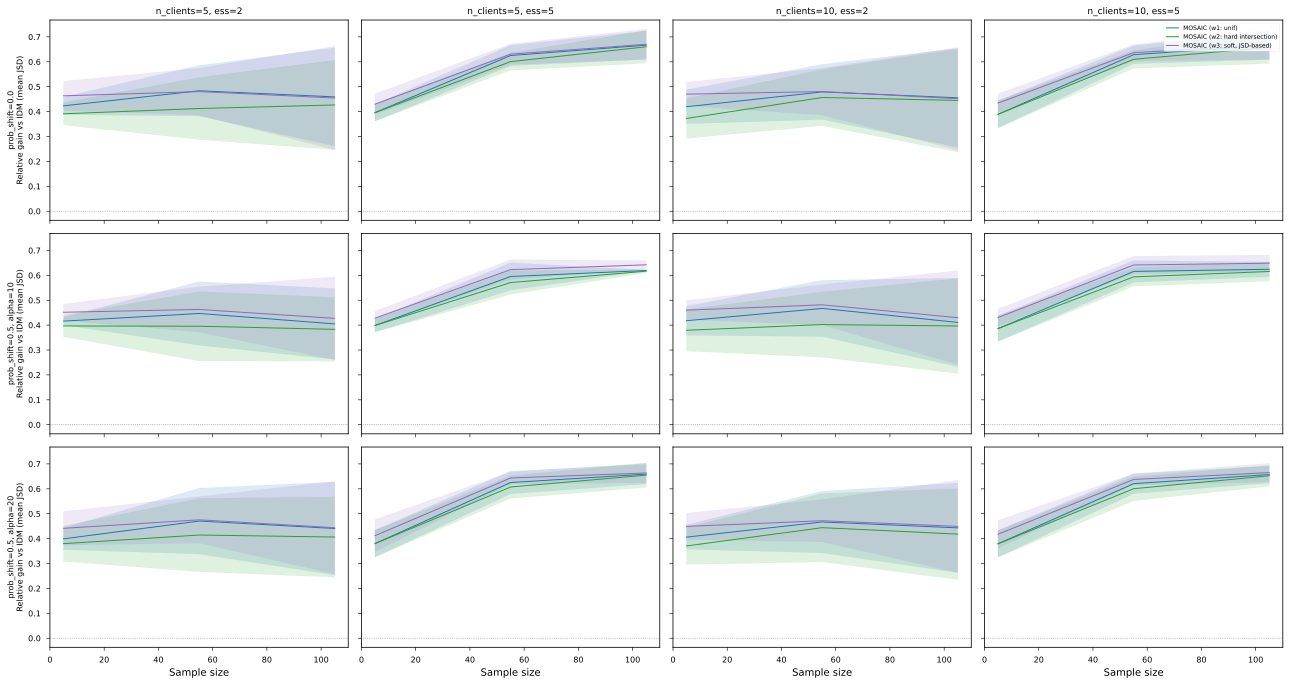

In [8]:
fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.2 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (p, a) in enumerate(row_vals):
    for j, (nc, ess) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        ax.axhline(0.0, color="gray", linewidth=0.7, linestyle=":")
        for w, color in mos_colors.items():
            m = sub[f"gain_w{w}"]
            s = sub[f"gain_w{w}_std"]
            ax.fill_between(sub["size"], m - s, m + s, color=color, alpha=0.15)
            ax.plot(sub["size"], m, color=color, label=mos_labels[w])

        if i == 0:
            ax.set_title(f"n_clients={nc}, ess={ess}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{row_label(p, a)}\nRelative gain vs IDM (mean JSD)", fontsize=8)
        if i == len(row_vals) - 1:
            ax.set_xlabel("Sample size")

axes[0][-1].legend(loc="upper right", fontsize=6)

plt.tight_layout()
plt.show()

fig.savefig(f"{res_path}_gain.svg", dpi=1200, bbox_inches="tight", transparent=False)

## Grafico 1.2: ground-truth containment ratio

Fraction of CPT entries across the network where the TRUE (ground-truth) parameters are actually contained in the credal set (`gt_containment_frac`, `src/utils.py`) -- the empirical check of "Reliability of credal sets" (`cap6_extract.tex`, Definition `as:credal`). Unlike $\widehat{\theta}^e$ (the MLE, always inside the local IDM credal set for any ess -- an algebraic fact, see `exp1.py`), containment of the true, unknown parameters is **not** guaranteed. This is expected to be MOSAIC's "negative" result: a narrower, more precise credal set can come at the cost of lower containment than IDM alone. Same mean $\pm$ std-across-repetitions band as Grafico 1.1.

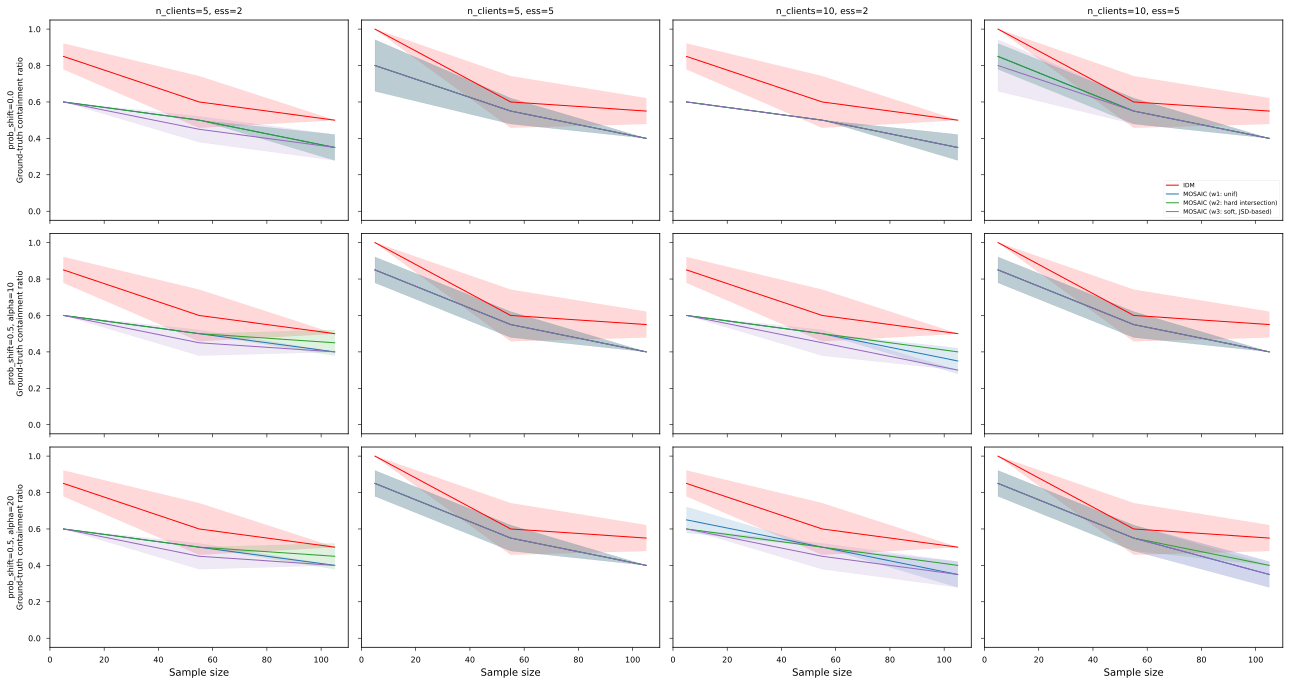

In [9]:
contain_colors = {"idm": "red", 1: "tab:blue", 2: "tab:green", 3: "tab:purple"}
contain_labels = {"idm": "IDM", 1: mos_labels[1], 2: mos_labels[2], 3: mos_labels[3]}

fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.2 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (p, a) in enumerate(row_vals):
    for j, (nc, ess) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        for kind, color in contain_colors.items():
            prefix = "idm_gt_contained" if kind == "idm" else f"mos_w{kind}_gt_contained"
            m = sub[prefix]
            s = sub[f"{prefix}_std"]
            ax.fill_between(sub["size"], m - s, m + s, color=color, alpha=0.15)
            ax.plot(sub["size"], m, color=color, label=contain_labels[kind])

        ax.set_ylim(-0.05, 1.05)
        if i == 0:
            ax.set_title(f"n_clients={nc}, ess={ess}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{row_label(p, a)}\nGround-truth containment ratio", fontsize=8)
        if i == len(row_vals) - 1:
            ax.set_xlabel("Sample size")

axes[0][-1].legend(loc="lower right", fontsize=6)

plt.tight_layout()
plt.show()

fig.savefig(f"{res_path}_containment.svg", dpi=1200, bbox_inches="tight", transparent=False)

## Loading a saved model (`results/models/<task_id>.pkl`)

Reference example for reading back a model saved by `exp1.py`. This is the pattern the global optimization phase will use to get $\theta^i_{X|\pi_X} \in K^{i+}_{X|\pi_X}$ from the saved, updated credal sets. **Always go through `lookup_cpt_row`**, never `cpt.topandas()` or a hand-rolled row index (see `snapshot_cpts`/`lookup_cpt_row` in `src/utils.py` for why).

Models are archived **one file per task** (`results/models/<n_clients>_<ess>_<prob_shift>_<alpha>_<size>_<rep>.pkl`, see `exp1.py`'s `_model_filename`) instead of a single `models.pkl` for the whole grid. Saving is also off by default for a plain local-learning-and-update sweep (`save_models: false` in `conf1.yaml`) since models are only needed for the global optimization phase; this demo only works when a run had `save_models: true`.

In [10]:
import pickle
from src.utils import lookup_cpt_row

models_dir = res_path / "models"
model_files = sorted(models_dir.glob("*.pkl"))
print(f"{len(model_files)} saved models found in {models_dir}")

# The filename itself IS the task_id (n_clients, ess, prob_shift, alpha, size, rep).
model_path = model_files[0]
print(
    "Example task_id (n_clients, ess, prob_shift, alpha, size, rep):", model_path.stem
)

with open(model_path, "rb") as f:
    model = pickle.load(f)
print("Available model kinds:", sorted(model.keys()))

# Read P(Cancer | Pollution, Smoker) from client 0's MOSAIC-updated credal
# set (weighting=3, lower bound), for one specific parent configuration.
entry = model["mos_w3_min"]["C"]
print("\nC's parent configurations (row order):", entry["parents"])
print("C's own category labels (column order):", entry["labels"])

row = lookup_cpt_row(entry, parents={"P": "low", "S": "True"})
print(
    "\nP(C | P=low, S=True)  [MOSAIC w3, lower bound] =",
    dict(zip(entry["labels"], row)),
)

# A root variable (no parents) is read the same way, with parents=None.
entry_p = model["bn_mle"]["P"]
print(
    "P(Pollution)  [client 0's exact MLE] =",
    dict(zip(entry_p["labels"], lookup_cpt_row(entry_p))),
)

72 saved models found in results1/models
Example task_id (n_clients, ess, prob_shift, alpha, size, rep): 10_2_0.0_10_105_0
Available model kinds: ['bn_mle', 'idm_max', 'idm_min', 'mos_w1_max', 'mos_w1_min', 'mos_w2_max', 'mos_w2_min', 'mos_w3_max', 'mos_w3_min', 'prior_w1_max', 'prior_w1_min', 'prior_w2_max', 'prior_w2_min', 'prior_w3_max', 'prior_w3_min']

C's parent configurations (row order): [{'P': 'low', 'S': 'True'}, {'P': 'high', 'S': 'True'}, {'P': 'low', 'S': 'False'}, {'P': 'high', 'S': 'False'}]
C's own category labels (column order): ['True', 'False']

P(C | P=low, S=True)  [MOSAIC w3, lower bound] = {'True': np.float64(0.03015699044476339), 'False': np.float64(0.9656773581785401)}
P(Pollution)  [client 0's exact MLE] = {'low': np.float64(0.9047619047619048), 'high': np.float64(0.09523809523809523)}
